In [12]:
!uv pip install dscribe ase

Using Python 3.13.11 environment at: C:\Users\asrosen\AppData\Local\miniconda3\envs\cms
Audited 2 packages in 20ms


In [13]:
import warnings

# Stops some annoying warnings from coming up
warnings.filterwarnings("ignore", category=SyntaxWarning)

# Reproducing a Paper

In this exercise, we will reproduce the resuls of the original [Coulomb matrix paper](https://link.aps.org/doi/10.1103/PhysRevLett.108.058301). Specifically, we will aim to predict the atomization energy of small organic molecules in the QM7 dataset.


First, we need to load in the dataset. These details are not important. The only thing that matters is that we will define `molecules` as our list of `Atoms` objects and `y` as our desired property (atomization energy).


In [ ]:
import os
import urllib.request
from ase.atoms import Atoms
from scipy.io import loadmat

url = "http://quantum-machine.org/data/qm7.mat"
filename = "qm7.mat"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)


data = loadmat(filename)
R = data["R"]  # atomic coordinates
Z = data["Z"]  # atomic numbers
y = data["T"].reshape(-1)  # atomization energies

molecules = []
for i in range(len(y)):
    mask = Z[i] > 0
    positions = R[i][mask]
    numbers = Z[i][mask]

    molecules.append(Atoms(numbers=numbers, positions=positions))

In [21]:
print(len(molecules))
print(len(y))

7165
7165


Let's take a look at the distribution of properties we want to predict to see if there are any anomalies to keep in mind.


Text(0, 0.5, 'Count')

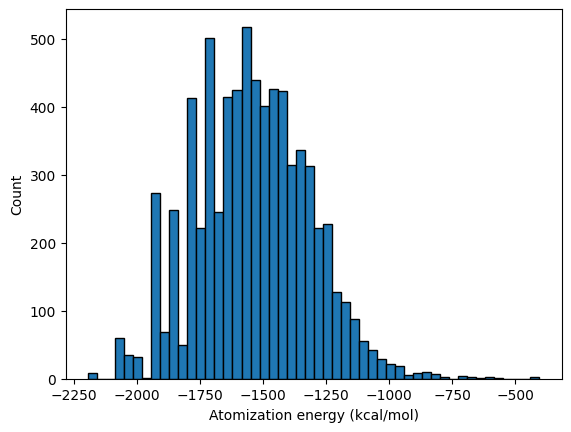

In [22]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50, edgecolor="k")
plt.xlabel("Atomization energy (kcal/mol)")
plt.ylabel("Count")

Now we will construct the Coulomb matrices using dscribe. We will flatten each matrix by taking the sorted eigenvalues. There are other options available via the `permutation` keyword argument as noted in [the documentation](https://singroup.github.io/dscribe/latest/tutorials/descriptors/coulomb_matrix.html#options-for-permutation).


In [ ]:
from dscribe.descriptors import CoulombMatrix

max_atoms = max([len(mol) for mol in molecules])

cm = CoulombMatrix(
    n_atoms_max=max_atoms,  # we need to pad the Coulomb matrices with 0s based on the largest structure
    permutation="eigenspectrum",  # we need to flatten the matrix to a 1D vector in some way
)
X = cm.create(
    molecules,  # this is our list of `Atoms` objects to featurize
    n_jobs=-1,  # this tells `dscribe` to run in parallel across our `Atoms` objects
)

In [25]:
X.shape

(7165, 23)

Now let's reproduce Figure 1a in the paper, in which we calculate the Euclidean distance metric for each pair of molecules.


In [ ]:
from sklearn.metrics import pairwise_distances

# NxN matrix describing distance in feature space
D = pairwise_distances(X, metric="euclidean", n_jobs=-1)

In [28]:
D.shape

(7165, 7165)

Text(0, 0.5, 'Frequency')

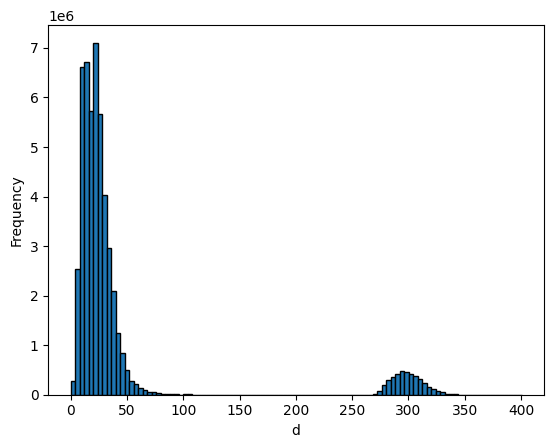

In [29]:
plt.hist(D.flatten(), bins=100, edgecolor="k")
plt.xlabel("d")
plt.ylabel("Frequency")

Now let's use the flattened Coulomb matrices to train a KRR model. For the sake of simplicity, we will do a bad thing and only have a training and testing set, with no validation set. We will assume some KRR hyperparameters are good. In practice, these hyperparameters would need to be tuned by minimizing the error in a validation set.


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [37]:
from sklearn.kernel_ridge import KernelRidge

model = KernelRidge(kernel="rbf", alpha=1e-5, gamma=1e-3)

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`. If an array is passed, penalties areassumed to be specific to the targets. Hence they must correspond innumber. See :ref:`ridge_regression` for formula.",1e-05
,"kernel kernel: str or callable, default=""linear""Kernel mapping used internally. This parameter is directly passed to:class:`~sklearn.metrics.pairwise.pairwise_kernels`.If `kernel` is a string, it must be one of the metricsin `pairwise.PAIRWISE_KERNEL_FUNCTIONS` or ""precomputed"".If `kernel` is ""precomputed"", X is assumed to be a kernel matrix.Alternatively, if `kernel` is a callable function, it is called oneach pair of instances (rows) and the resulting value recorded. Thecallable should take two rows from X as input and return thecorresponding kernel value as a single number. This means thatcallables from :mod:`sklearn.metrics.pairwise` are not allowed, asthey operate on matrices, not single samples. Use the stringidentifying the kernel instead.",'rbf'
,"gamma gamma: float, default=NoneGamma parameter for the RBF, laplacian, polynomial, exponential chi2and sigmoid kernels. Interpretation of the default value is left tothe kernel; see the documentation for sklearn.metrics.pairwise.Ignored by other kernels.",0.001
,"degree degree: float, default=3Degree of the polynomial kernel. Ignored by other kernels.",3
,"coef0 coef0: float, default=1Zero coefficient for polynomial and sigmoid kernels.Ignored by other kernels.",1
,"kernel_params kernel_params: dict, default=NoneAdditional parameters (keyword arguments) for kernel function passedas callable object.",None


In [38]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Test MAE: {mae} kcal/mol")

Test MAE: 9.829140028339785 kcal/mol


Now we reproduce the parity plot in Figure 2b. Look sgood!


Text(0.5, 0, 'Ground Truth Atomization Energy (kcal/mol)')

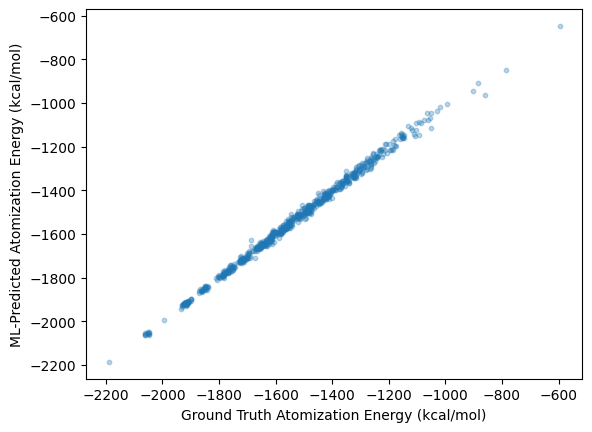

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.ylabel("ML-Predicted Atomization Energy (kcal/mol)")
plt.xlabel("Ground Truth Atomization Energy (kcal/mol)")

# Exercise

Try to reproduce the learning curve shown in Figure 2a. Note that the x-axis is actually N, not log2(N). The spacing is just on a log spacing.


Train size: 500, Test MAE: 26.58337320210874 kcal/mol
Train size: 813, Test MAE: 21.018531134913694 kcal/mol
Train size: 1126, Test MAE: 18.80302039430548 kcal/mol
Train size: 1439, Test MAE: 15.972162147554657 kcal/mol
Train size: 1752, Test MAE: 13.532180365029815 kcal/mol
Train size: 2065, Test MAE: 12.50959392253954 kcal/mol
Train size: 2378, Test MAE: 12.575712328263956 kcal/mol
Train size: 2691, Test MAE: 12.018022023372735 kcal/mol
Train size: 3004, Test MAE: 11.336777561425349 kcal/mol
Train size: 3317, Test MAE: 10.93794952591318 kcal/mol
Train size: 3630, Test MAE: 10.787804681674995 kcal/mol
Train size: 3943, Test MAE: 10.429222460519087 kcal/mol
Train size: 4256, Test MAE: 10.21816574458833 kcal/mol
Train size: 4569, Test MAE: 9.954540757295423 kcal/mol
Train size: 4882, Test MAE: 10.080798429319012 kcal/mol
Train size: 5195, Test MAE: 10.04875246408767 kcal/mol
Train size: 5508, Test MAE: 10.014334237504837 kcal/mol
Train size: 5821, Test MAE: 10.103534962619356 kcal/mol
T

Text(0, 0.5, 'Error [kcal/mol]')

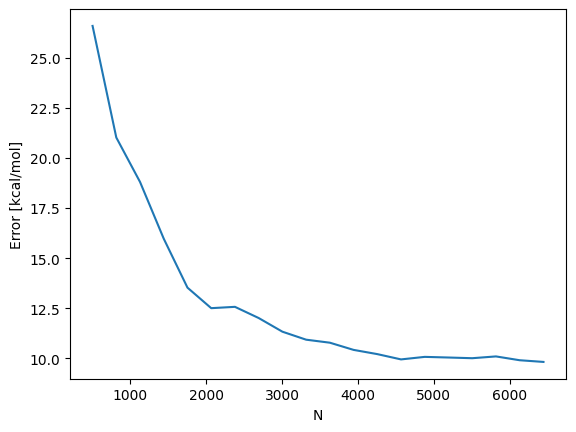

In [ ]:
import numpy as np

maes = []
train_sizes = np.linspace(500, len(y_train), 20, dtype=int)
for train_size in train_sizes:
    X_train_sample = X_train[0:train_size]
    y_train_sample = y_train[0:train_size]

    model = KernelRidge(kernel="rbf", alpha=1e-5, gamma=1e-3)

    model.fit(X_train_sample, y_train_sample)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    maes.append(mae)

    print(f"Train size: {train_size}, Test MAE: {mae} kcal/mol")
plt.plot(train_sizes, maes)
plt.xlabel("N")
plt.ylabel("Error [kcal/mol]")